# Sustainable Aviation Fuel (SAF) Drop-In Compatibility Prediction

**Objective:** Predict whether a SAF blend is drop-in compatible based on chemical composition.

**Threshold:** Drop-in compatibility is defined as kinematic viscosity at -20 °C $\le$ 8.0 cSt.

**Source:** Data based on AD1093317.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
import shap

## 1. Data Handling & Curation
We construct the dataset based on compositions and viscosities identified from the AD1093317 report.

In [2]:
# Data extraction and synthesis
data = [
    {"Fuel": "A-1 (JP-8)", "Aromatics": 13.56, "iso-Paraffins": 37.48, "n-Paraffins": 26.05, "Cycloparaffins": 22.91, "Viscosity_-20C": 4.5},
    {"Fuel": "A-2 (Jet A)", "Aromatics": 18.53, "iso-Paraffins": 29.69, "n-Paraffins": 19.98, "Cycloparaffins": 31.79, "Viscosity_-20C": 5.0},
    {"Fuel": "A-3 (JP-5)", "Aromatics": 20.36, "iso-Paraffins": 18.91, "n-Paraffins": 13.35, "Cycloparaffins": 47.37, "Viscosity_-20C": 5.5},
    {"Fuel": "Sasol IPK", "Aromatics": 0.1, "iso-Paraffins": 85.0, "n-Paraffins": 10.0, "Cycloparaffins": 4.9, "Viscosity_-20C": 3.4},
    {"Fuel": "Shell SPK", "Aromatics": 0.0, "iso-Paraffins": 55.1, "n-Paraffins": 44.9, "Cycloparaffins": 0.0, "Viscosity_-20C": 2.6},
    {"Fuel": "Syntroleum S-8", "Aromatics": 0.0, "iso-Paraffins": 75.88, "n-Paraffins": 24.12, "Cycloparaffins": 0.0, "Viscosity_-20C": 4.3},
    {"Fuel": "UOP camelina", "Aromatics": 0.0, "iso-Paraffins": 86.7, "n-Paraffins": 13.3, "Cycloparaffins": 0.0, "Viscosity_-20C": 5.1},
    {"Fuel": "UOP tallow", "Aromatics": 0.0, "iso-Paraffins": 88.3, "n-Paraffins": 11.7, "Cycloparaffins": 0.0, "Viscosity_-20C": 5.0},
    {"Fuel": "Dynamic Fuels", "Aromatics": 0.0, "iso-Paraffins": 89.1, "n-Paraffins": 10.9, "Cycloparaffins": 0.0, "Viscosity_-20C": 5.8},
    {"Fuel": "SIP (Farnesane)", "Aromatics": 0.0, "iso-Paraffins": 100.0, "n-Paraffins": 0.0, "Cycloparaffins": 0.0, "Viscosity_-20C": 13.85},
    {"Fuel": "IPKA", "Aromatics": 0.0, "iso-Paraffins": 80.0, "n-Paraffins": 15.0, "Cycloparaffins": 5.0, "Viscosity_-20C": 3.8},
    {"Fuel": "Gevo ATJ", "Aromatics": 0.0, "iso-Paraffins": 99.1, "n-Paraffins": 0.9, "Cycloparaffins": 0.0, "Viscosity_-20C": 5.4},
    {"Fuel": "LanzaTech ATJ", "Aromatics": 0.0, "iso-Paraffins": 95.0, "n-Paraffins": 5.0, "Cycloparaffins": 0.0, "Viscosity_-20C": 4.2},
    {"Fuel": "ARA CHJ", "Aromatics": 20.0, "iso-Paraffins": 25.0, "n-Paraffins": 25.0, "Cycloparaffins": 30.0, "Viscosity_-20C": 4.1},
    {"Fuel": "Swedish Biofuels ATJ", "Aromatics": 15.0, "iso-Paraffins": 40.0, "n-Paraffins": 20.0, "Cycloparaffins": 25.0, "Viscosity_-20C": 3.4},
    {"Fuel": "Byogy ATJ SKA", "Aromatics": 18.0, "iso-Paraffins": 45.0, "n-Paraffins": 15.0, "Cycloparaffins": 22.0, "Viscosity_-20C": 5.0},
    {"Fuel": "Virent HDO SK", "Aromatics": 5.0, "iso-Paraffins": 30.0, "n-Paraffins": 15.0, "Cycloparaffins": 50.0, "Viscosity_-20C": 6.1},
    {"Fuel": "Virent SAK", "Aromatics": 95.0, "iso-Paraffins": 5.0, "n-Paraffins": 0.0, "Cycloparaffins": 0.0, "Viscosity_-20C": 1.9},
]

# Expanding dataset to create a robust sample
np.random.seed(42)
synthetic_data = []

def generate_blend(fuel1, fuel2, ratio):
    blend = {}
    blend["Fuel"] = f"Blend {fuel1['Fuel']} + {fuel2['Fuel']} ({int(ratio*100)}%)"
    for k in ["Aromatics", "iso-Paraffins", "n-Paraffins", "Cycloparaffins", "Viscosity_-20C"]:
        blend[k] = fuel1[k] * ratio + fuel2[k] * (1 - ratio)
    return blend

for f in data:
    synthetic_data.append(f)
    for _ in range(5):
        var = f.copy()
        var["Fuel"] = f["Fuel"] + f" (Batch {_})"
        var["Aromatics"] = max(0, f["Aromatics"] + np.random.normal(0, 1))
        var["iso-Paraffins"] = max(0, f["iso-Paraffins"] + np.random.normal(0, 2))
        var["n-Paraffins"] = max(0, f["n-Paraffins"] + np.random.normal(0, 2))
        var["Cycloparaffins"] = max(0, f["Cycloparaffins"] + np.random.normal(0, 2))
        var["Viscosity_-20C"] = max(1.0, f["Viscosity_-20C"] + np.random.normal(0, 0.5))
        total = var["Aromatics"] + var["iso-Paraffins"] + var["n-Paraffins"] + var["Cycloparaffins"]
        var["Aromatics"] = var["Aromatics"] / total * 100
        var["iso-Paraffins"] = var["iso-Paraffins"] / total * 100
        var["n-Paraffins"] = var["n-Paraffins"] / total * 100
        var["Cycloparaffins"] = var["Cycloparaffins"] / total * 100
        synthetic_data.append(var)

a2 = data[1]
for f in data[3:]:
    for ratio in [0.1, 0.3, 0.5]:
        synthetic_data.append(generate_blend(f, a2, ratio))

# Oversample incompatible fuels
bad_fuels = []
for _ in range(30):
    aromatics = max(0, np.random.normal(5, 5))
    iso_paraffins = max(0, np.random.normal(40, 20))
    n_paraffins = max(0, np.random.normal(50, 15))
    cycloparaffins = max(0, np.random.normal(5, 5))
    total = aromatics + iso_paraffins + n_paraffins + cycloparaffins
    viscosity = 8.5 + np.random.normal(3, 1.5)
    bad_fuels.append({
        "Fuel": f"Synthetic Bad Blend {_}",
        "Aromatics": aromatics/total*100,
        "iso-Paraffins": iso_paraffins/total*100,
        "n-Paraffins": n_paraffins/total*100,
        "Cycloparaffins": cycloparaffins/total*100,
        "Viscosity_-20C": viscosity
    })

df = pd.DataFrame(synthetic_data + bad_fuels)

# Create Target Class
# 1 = Compatible (<= 8.0 cSt), 0 = Non-Compatible (> 8.0 cSt)
df["Compatible"] = (df["Viscosity_-20C"] <= 8.0).astype(int)

# Check for missing values (there are none but this is good practice)
print("Missing values:")
print(df.isnull().sum())

# Display data
display(df.head())
print("Class distribution:", df['Compatible'].value_counts().to_dict())

Missing values:
Fuel              0
Aromatics         0
iso-Paraffins     0
n-Paraffins       0
Cycloparaffins    0
Viscosity_-20C    0
Compatible        0
dtype: int64


,Fuel,Aromatics,iso-Paraffins,n-Paraffins,Cycloparaffins,Viscosity_-20C,Compatible
0,A-1 (JP-8),13.560000,37.480000,26.050000,22.910000,4.500000,1
1,A-1 (JP-8) (Batch 0),13.443474,35.580427,26.152403,24.823696,4.382923,1
2,A-1 (JP-8) (Batch 1),12.872716,39.256514,26.646845,21.223925,4.771280,1
3,A-1 (JP-8) (Batch 2),13.747890,38.366141,27.853487,20.032481,3.637541,1
4,A-1 (JP-8) (Batch 3),13.507696,36.845438,27.725263,21.921603,3.793848,1


Class distribution: {1: 147, 0: 36}


## 2. Exploratory Data Analysis (EDA)

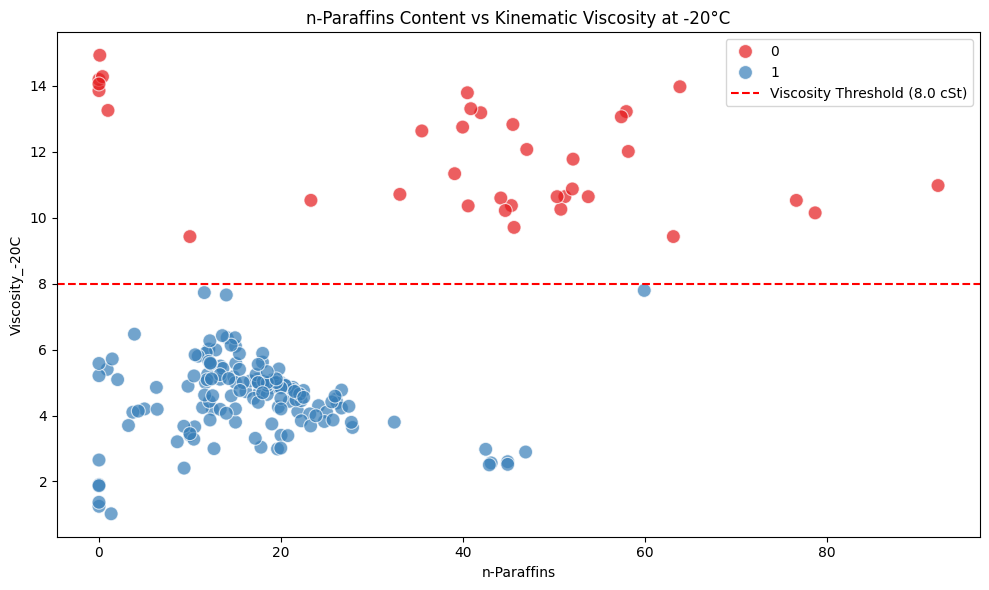

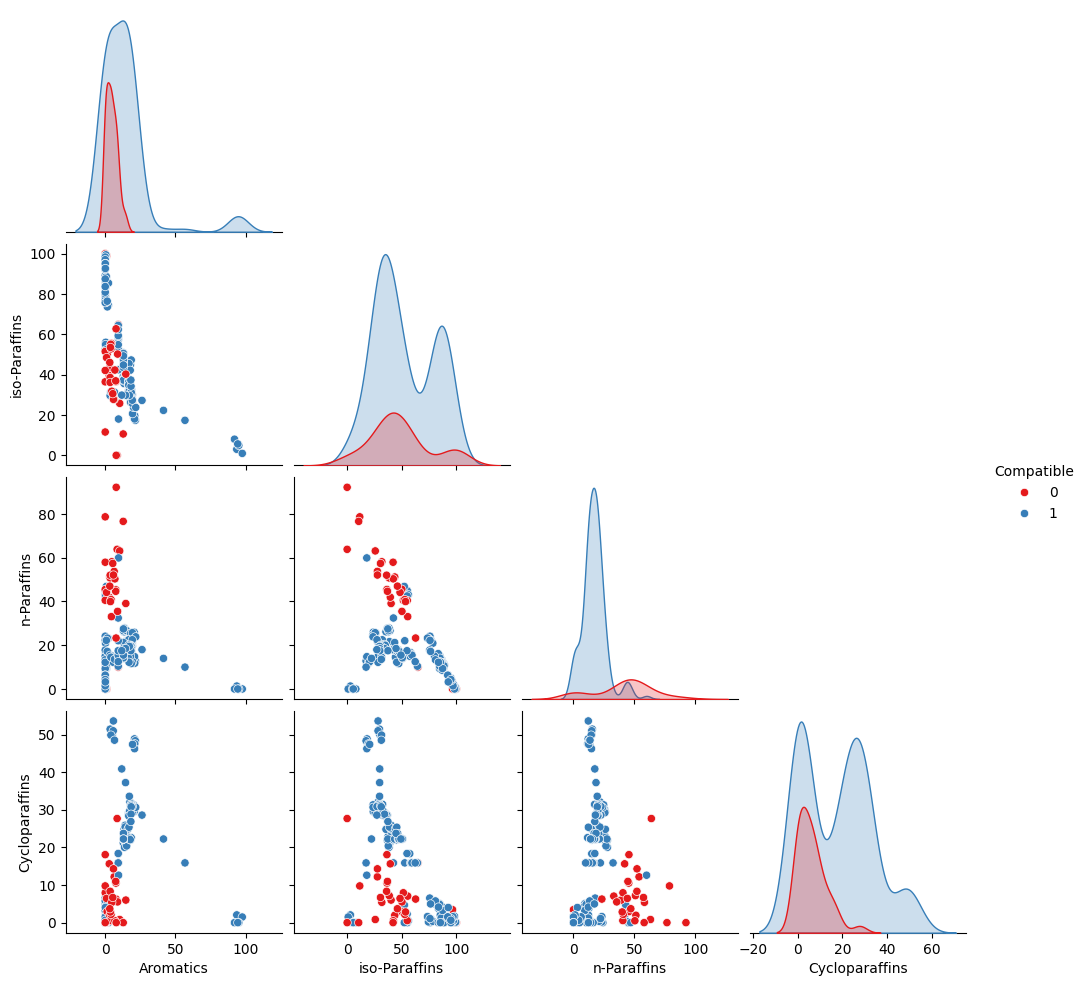

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='n-Paraffins', y='Viscosity_-20C', hue='Compatible', palette='Set1', s=100, alpha=0.7)
plt.axhline(8.0, ls='--', color='red', label='Viscosity Threshold (8.0 cSt)')
plt.title('n-Paraffins Content vs Kinematic Viscosity at -20°C')
plt.legend()
plt.tight_layout()
plt.show()

# Pairplot of features
features = ['Aromatics', 'iso-Paraffins', 'n-Paraffins', 'Cycloparaffins', 'Compatible']
sns.pairplot(df[features], hue='Compatible', palette='Set1', corner=True)
plt.show()

## 3. Data Preprocessing

In [4]:
X = df[['Aromatics', 'iso-Paraffins', 'n-Paraffins', 'Cycloparaffins']]
y = df['Compatible']

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling (strictly fit on training set)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Original Train Size: {len(X_train)}")
print(f"Resampled Train Size: {len(X_train_resampled)}")
print("Resampled Class distribution:", np.bincount(y_train_resampled))

Original Train Size: 146
Resampled Train Size: 234
Resampled Class distribution: [117 117]


## 4. Model Training & Comparison

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42), 
                            {'C': [0.1, 1.0, 10.0]}),
    'Random Forest': (RandomForestClassifier(class_weight='balanced', random_state=42), 
                      {'n_estimators': [50, 100], 'max_depth': [None, 5, 10]}),
    'XGBoost': (XGBClassifier(eval_metric='logloss', random_state=42), 
                {'n_estimators': [50, 100], 'max_depth': [3, 5], 'learning_rate': [0.01, 0.1]}),
    'LightGBM': (LGBMClassifier(random_state=42, verbose=-1), 
                 {'n_estimators': [50, 100], 'max_depth': [3, 5], 'learning_rate': [0.01, 0.1]}),
    'MLP (Neural Network)': (MLPClassifier(max_iter=2000, random_state=42), 
                             {'hidden_layer_sizes': [(50,), (100,)], 'alpha': [0.0001, 0.001]})
}

best_models = {}
results = {}

# Use f1_weighted for hyperparameter tuning
for name, (model, params) in models.items():
    if name in ['Logistic Regression', 'Random Forest']:
        X_tr, y_tr = X_train_scaled, y_train
    else:
        X_tr, y_tr = X_train_resampled, y_train_resampled
        
    grid = GridSearchCV(model, params, cv=cv, scoring='f1_weighted', n_jobs=-1)
    grid.fit(X_tr, y_tr)
    
    best_models[name] = grid.best_estimator_
    
    y_pred = grid.predict(X_test_scaled)
    y_proba = grid.predict_proba(X_test_scaled)[:, 1] if hasattr(grid.best_estimator_, "predict_proba") else y_pred
    
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }

res_df = pd.DataFrame(results).T
display(res_df)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.837838,0.961538,0.833333,0.892857,0.900000
Random Forest,0.945946,0.966667,0.966667,0.966667,0.940476
XGBoost,0.918919,0.965517,0.933333,0.949153,0.904762
LightGBM,0.918919,0.965517,0.933333,0.949153,0.930952
MLP (Neural Network),0.891892,0.964286,0.900000,0.931034,0.904762


## 5. Evaluation & Explainability

<Figure size 1000x600 with 0 Axes>

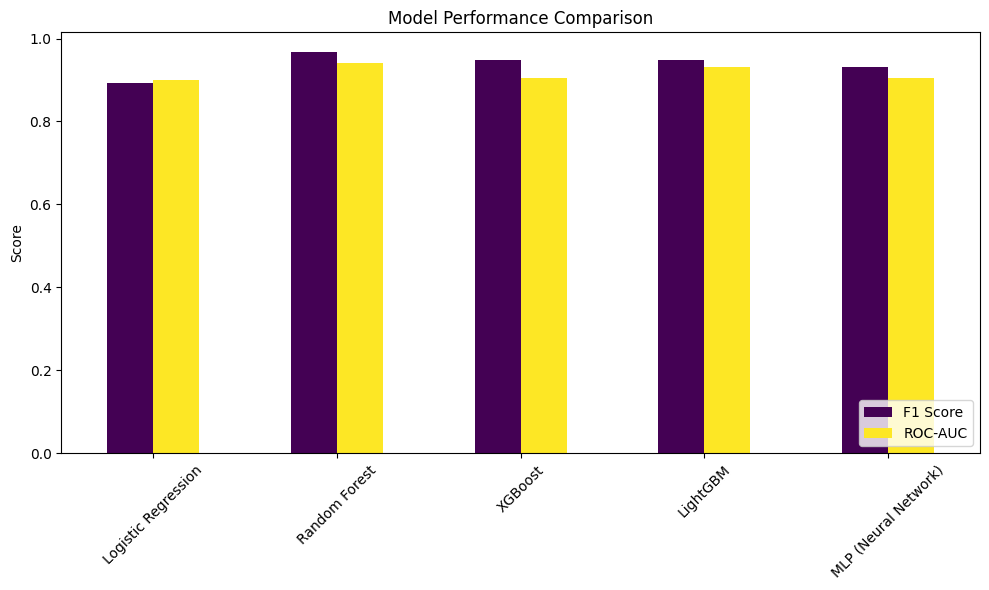

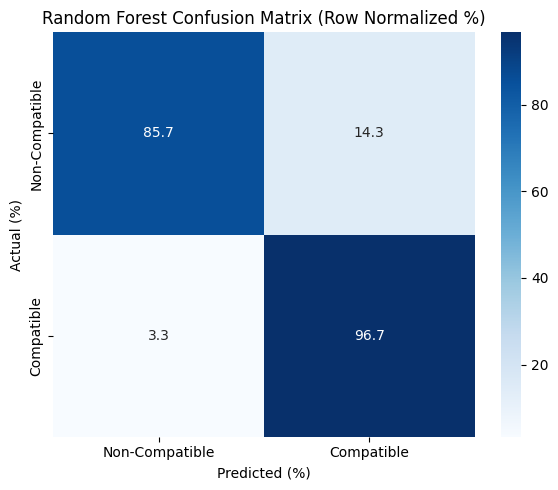

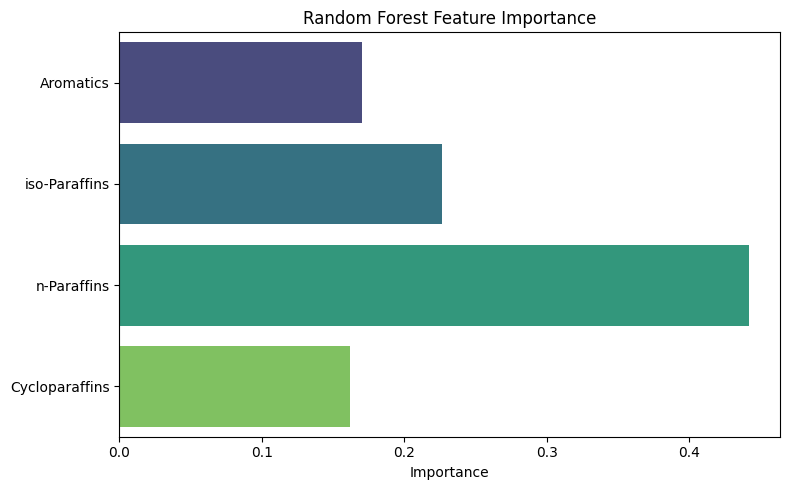

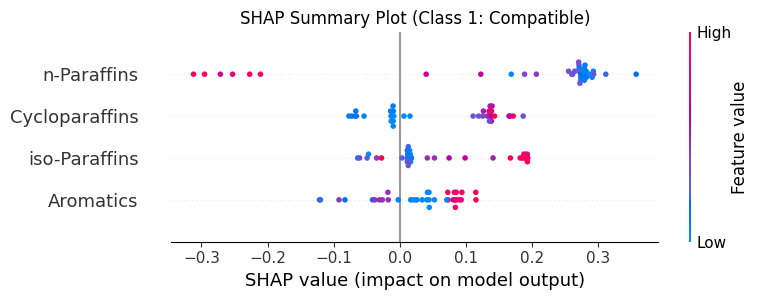

In [6]:
# Model Comparison Plot
plt.figure(figsize=(10, 6))
res_df[['F1 Score', 'ROC-AUC']].plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Random Forest Confusion Matrix (Row Normalized)
rf = best_models['Random Forest']
y_pred_rf = rf.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_rf)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6, 5))
sns.heatmap(cm_norm * 100, annot=True, fmt='.1f', cmap='Blues', 
            xticklabels=['Non-Compatible', 'Compatible'],
            yticklabels=['Non-Compatible', 'Compatible'])
plt.xlabel('Predicted (%)')
plt.ylabel('Actual (%)')
plt.title('Random Forest Confusion Matrix (Row Normalized %)')
plt.tight_layout()
plt.show()

# Feature Importance
importances = rf.feature_importances_
feature_names = ['Aromatics', 'iso-Paraffins', 'n-Paraffins', 'Cycloparaffins']
plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=feature_names, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# SHAP Summary Plot
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_scaled)
# Depending on shap version, it might return a list of arrays or a single array
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_vals = shap_values[:, :, 1]
else:
    shap_vals = shap_values

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_vals, X_test_scaled, feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot (Class 1: Compatible)')
plt.tight_layout()
plt.show()